In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
df = pd.read_csv("Enter the Dataset path here")

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (101371, 16)

Columns:
['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']

First 5 rows:
  Driver  LapNumber Compound  Stint  TyreLife  Position  LapTime (s)  \
0    ALB          1   MEDIUM      1       2.0        17      100.625   
1    ALB          2   MEDIUM      1       3.0        18       93.560   
2    ALB          3   MEDIUM      1       4.0        18       91.768   
3    ALB          4   MEDIUM      1       5.0        18       91.591   
4    ALB          5   MEDIUM      1       6.0        18       91.422   

                   Race  Year  LapTime_Delta  Cumulative_Degradation  PitStop  \
0  Abu Dhabi Grand Prix  2023          0.000                   0.000        0   
1  Abu Dhabi Grand Prix  2023         -7.065                  -7.065        0   
2  Abu Dhabi Grand Prix  2023         -1.7

In [5]:
#Data preprocessing

# Sort chronologically
df = df.sort_values(['Year', 'Race', 'Driver', 'LapNumber']).reset_index(drop=True)

# Check missing values
print("\nMissing values before preprocessing:")
print(df.isnull().sum())

# Median imputation for selected numeric columns
cols_to_impute = ['LapTime (s)', 'TyreLife']
imputer = SimpleImputer(strategy='median')
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

# Encode categorical columns needed for modelling
label_enc_driver = LabelEncoder()
label_enc_compound = LabelEncoder()
label_enc_race = LabelEncoder()

df['Driver_encoded'] = label_enc_driver.fit_transform(df['Driver'])
df['Compound_encoded'] = label_enc_compound.fit_transform(df['Compound'])
df['Race_encoded'] = label_enc_race.fit_transform(df['Race'])

print("\nMissing values after preprocessing:")
print(df.isnull().sum())


Missing values before preprocessing:
Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

Missing values after preprocessing:
Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Chan


Target distribution:
PitStop
0    75868
1    25503
Name: count, dtype: int64


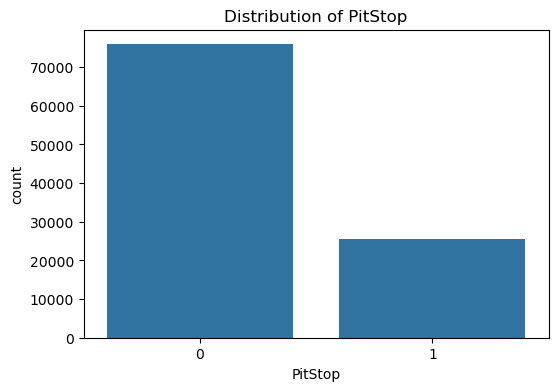

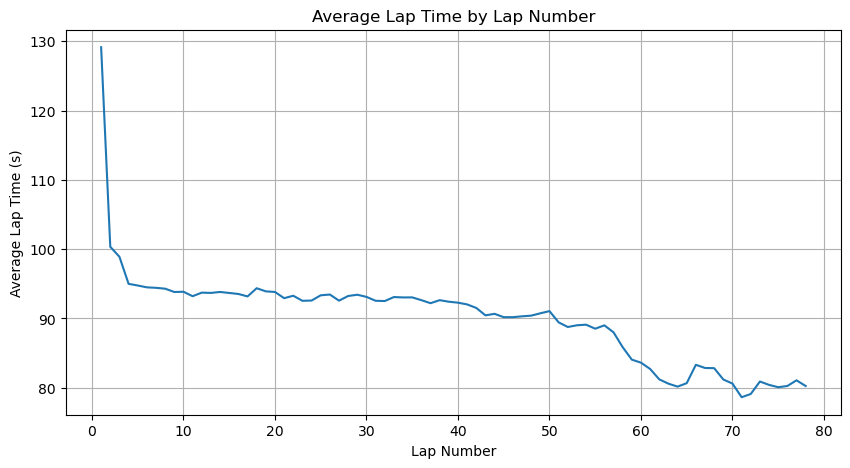

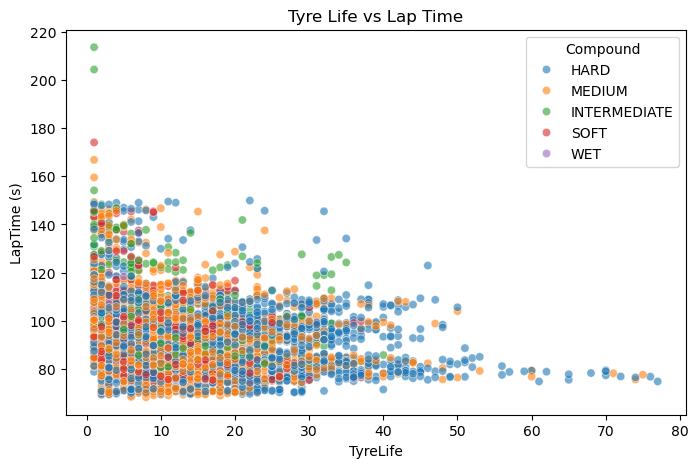

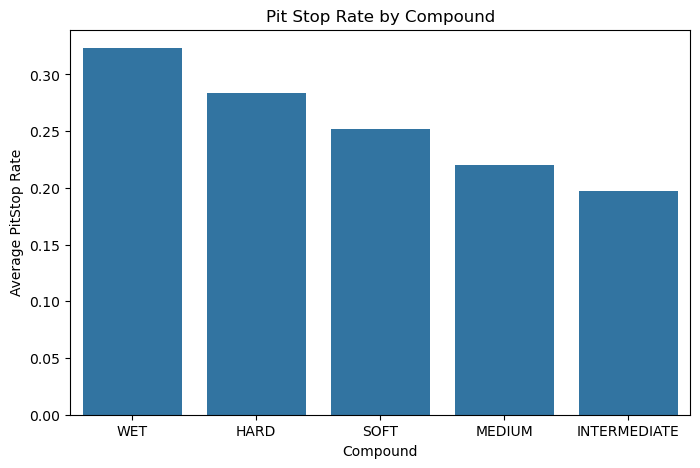

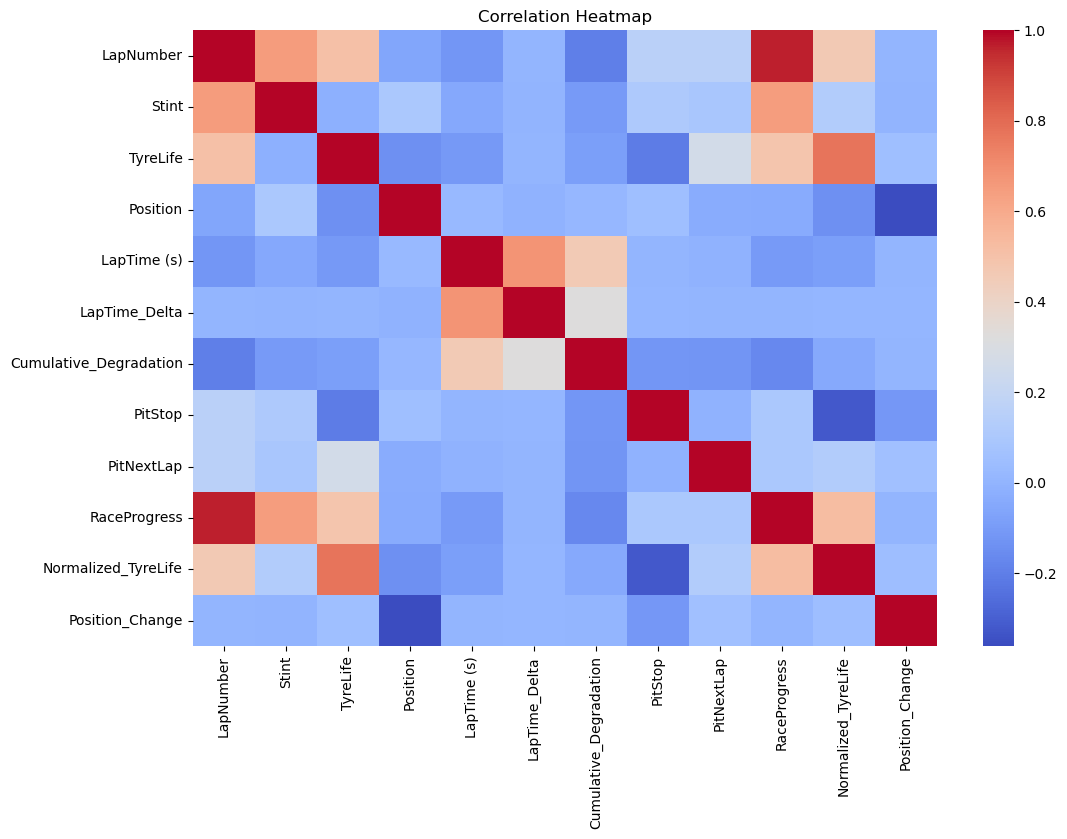

In [6]:
#Exploratory Data Analysis

print("\nTarget distribution:")
print(df['PitStop'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='PitStop', data=df)
plt.title('Distribution of PitStop')
plt.show()

plt.figure(figsize=(10,5))
lap_avg = df.groupby('LapNumber')['LapTime (s)'].mean()
plt.plot(lap_avg.index, lap_avg.values)
plt.title('Average Lap Time by Lap Number')
plt.xlabel('Lap Number')
plt.ylabel('Average Lap Time (s)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x='TyreLife',
    y='LapTime (s)',
    hue='Compound',
    alpha=0.6
)
plt.title('Tyre Life vs Lap Time')
plt.show()

plt.figure(figsize=(8,5))
pit_rate_compound = df.groupby('Compound')['PitStop'].mean().sort_values(ascending=False)
sns.barplot(x=pit_rate_compound.index, y=pit_rate_compound.values)
plt.title('Pit Stop Rate by Compound')
plt.ylabel('Average PitStop Rate')
plt.show()

plt.figure(figsize=(12,8))
numeric_cols_eda = [
    'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'PitStop',
    'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change'
]
sns.heatmap(df[numeric_cols_eda].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()


In [7]:
#Feature engineering
# Rolling pace trend per race and driver
df['Pace_Trend'] = df.groupby(['Year', 'Race', 'Driver'])['LapTime (s)'] \
                     .transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Lag feature
df['LapTime_lag1'] = df.groupby(['Year', 'Race', 'Driver'])['LapTime (s)'].shift(1)

# Fill lag NaN using median
df['LapTime_lag1'] = df['LapTime_lag1'].fillna(df['LapTime_lag1'].median())

print("\nFeature engineered columns added: Pace_Trend, LapTime_lag1")


Feature engineered columns added: Pace_Trend, LapTime_lag1


In [8]:
# Feature selection

feature_cols = [
    'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'LapTime_Delta', 'Cumulative_Degradation', 'PitNextLap',
    'RaceProgress', 'Normalized_TyreLife', 'Position_Change',
    'Driver_encoded', 'Compound_encoded', 'Race_encoded',
    'Pace_Trend', 'LapTime_lag1'
]

X = df[feature_cols]
y = df['PitStop']


In [9]:
# Feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
#Feature extraction using PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print("\nExplained variance ratio by PCA:")
print(pca.explained_variance_ratio_)


Explained variance ratio by PCA:
[0.21829424 0.16131719 0.09726658 0.07851443 0.07229819]


In [11]:
#Cross validation

tscv = TimeSeriesSplit(n_splits=5)

In [12]:
# 10. Hyperparameter tuning

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_pca, y)

print("\nBest Parameters:")
print(grid.best_params_)
print("Best Cross Validation F1 Score:", grid.best_score_)


Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
Best Cross Validation F1 Score: 0.4827360577984051


In [13]:
#Train-test split using final time split

splits = list(tscv.split(X_pca))
train_idx, test_idx = splits[-1]

X_train, X_test = X_pca[train_idx], X_pca[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [14]:
#Model training and testing

best_model = RandomForestClassifier(
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    min_samples_split=grid.best_params_['min_samples_split'],
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)


Accuracy: 0.7416987274341521
F1 Score: 0.6244406196213426

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80     11035
           1       0.63      0.62      0.62      5860

    accuracy                           0.74     16895
   macro avg       0.71      0.71      0.71     16895
weighted avg       0.74      0.74      0.74     16895



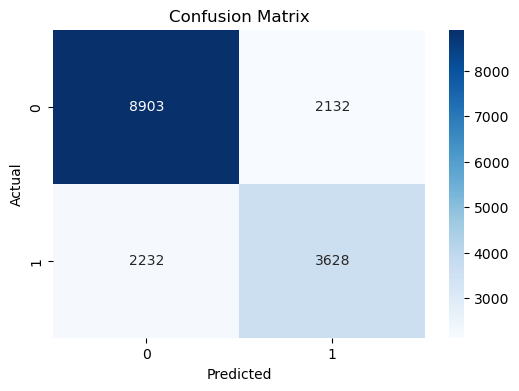

In [15]:
#Model evaluation

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()